# 사용할 코드만 정리

In [1]:
# 도구 불러오기
import pandas as pd
import numpy as np
import glob
import os
import re
import ast
from glob import glob
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.font_manager as fm

# 판다스 출력 제한 해제 
pd.set_option('display.max_rows', 100) # 최대 100행까지 생략 없이 출력
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 1000)

In [2]:
# 원본 메타데이터 로드
df_meta = pd.read_csv("../../dataset/metadata.csv")

In [3]:
# 전처리 (시간/수치형(Capacity, Re, Rct)/file_num 파생)

def clean_parse_time(x):
    if pd.isna(x):
        return pd.NaT
    
    try:
        s = str(x)
        pattern = r"[-+]?\d*\.?\d+[eE][-+]?\d+|[-+]?\d+\.?\d*"
        parts = re.findall(pattern, s)
        
        if len(parts) < 3:
            return pd.NaT
        
        nums = [float(p) for p in parts]
        
        year   = int(nums[0])
        month  = int(nums[1])
        day    = int(nums[2])
        hour   = int(nums[3]) if len(nums) > 3 else 0
        minute = int(nums[4]) if len(nums) > 4 else 0
        
        # 핵심: round 제거
        second = int(nums[5]) if len(nums) > 5 else 0
        
        return pd.Timestamp(year=year, month=month, day=day,
                            hour=hour, minute=minute, second=second)
    
    except Exception as e:
        print(f"[파싱 실패] {x} | {e}")
        return pd.NaT

def clean_numeric(x):
    """수치형 데이터의 대괄호 제거 및 float 변환"""
    if pd.isna(x): return np.nan
    val = str(x).replace('[', '').replace(']', '').strip()
    try:
        return float(val)
    except:
        return np.nan

# --- [전처리 실행] ---
df = df_meta.copy()

# 1. 시간 데이터 정제 (소수점 초까지 완벽 대응)
df['start_time'] = df['start_time'].apply(clean_parse_time)

# 2. 수치형 데이터 정제 (Capacity, Re, Rct)
for col in ['Capacity', 'Re', 'Rct']:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

# 3. 물리적 순서 정렬 (파일 번호 기준)
df['file_num'] = df['filename'].str.extract(r'(\d+)').astype(int)
df = df.sort_values(['battery_id', 'file_num']).reset_index(drop=True)

# 최종 결과 검증
print(f"전체 데이터 개수: {len(df):,}개")
print(f"시간 결측치(NaT): {df['start_time'].isna().sum()}개")
print(f"수치형 결측치(Cap): {df['Capacity'].isna().sum()}개")


전체 데이터 개수: 7,565개
시간 결측치(NaT): 0개
수치형 결측치(Cap): 4796개


In [ ]:
df

In [4]:
#####
# metadata df에서 B0005만 필터링하여 시간순 정렬

# 판다스 출력 옵션 설정 (최대 행/열 제한 해제)
pd.set_option('display.max_rows', None)  # 모든 행 출력
pd.set_option('display.max_columns', None)  # 모든 열 출력
pd.set_option('display.width', None)  # 줄바꿈 없이 출력
pd.set_option('display.max_colwidth', None) # 컬럼 내용 생략 없이 출력

# 생성
B0005_timeline = df[df['battery_id'] == 'B0005'].copy()

# 시간순 정렬 후 주요 컬럼만 출력
# 'type', 'start_time', 'cycle'을 중심으로 나열
check_cols = ['type', 'start_time','test_id', 'filename', 'Capacity','Re','Rct']
display(B0005_timeline[check_cols].sort_values('start_time'))

# 출력이 끝난 후 옵션을 다시 기본값으로 되돌리고 싶다면 (선택사항)
# pd.reset_option('all')

,type,start_time,test_id,filename,Capacity,Re,Rct
0,charge,2008-04-02 13:08:17,0,05121.csv,NaN,NaN,NaN
1,discharge,2008-04-02 15:25:41,1,05122.csv,1.856487,NaN,NaN
2,charge,2008-04-02 16:37:51,2,05123.csv,NaN,NaN,NaN
3,discharge,2008-04-02 19:43:48,3,05124.csv,1.846327,NaN,NaN
4,charge,2008-04-02 20:55:40,4,05125.csv,NaN,NaN,NaN
5,discharge,2008-04-03 00:01:06,5,05126.csv,1.835349,NaN,NaN
6,charge,2008-04-03 01:12:38,6,05127.csv,NaN,NaN,NaN
7,discharge,2008-04-03 04:16:37,7,05128.csv,1.835263,NaN,NaN
8,charge,2008-04-03 05:27:49,8,05129.csv,NaN,NaN,NaN
9,discharge,2008-04-03 08:33:25,9,05130.csv,1.834646,NaN,NaN


# 진행전 먼저 B0005를 메타에서 가져와서 병합해야할것같다

In [5]:


# 1. 설정
target_id = 'B0005'
data_folder = "../../dataset/data" 
# 메타데이터에서 B0005만 추출 (조인할 원본 소스)
meta_b0005 = df[df['battery_id'] == target_id].sort_values('start_time').copy()

# 2. EOL 계산 (RUL 산출용)
dis_only = meta_b0005[meta_b0005['type'] == 'discharge']
first_cap = dis_only['Capacity'].iloc[0] if not dis_only.empty else 0
eol_idx = np.where((dis_only['Capacity'] / first_cap) * 100 <= 80)[0]
eol_cycle_num = eol_idx[0] + 1 if len(eol_idx) > 0 else np.nan

# 3. 통합 저장소
all_data_list = []
# 타입별 내부 사이클 카운터
counters = {'charge': 1, 'discharge': 1, 'impedance': 1}

discharge_cycle_counter = 0

# 4. 루프 및 조인
for _, row in meta_b0005.iterrows():
    file_path = os.path.join(data_folder, row['filename'])
    
    if os.path.exists(file_path):
        temp_df = pd.read_csv(file_path)
        d_type = row['type']
        
        # (A) 메타데이터 주입
        for col in meta_b0005.columns:
            temp_df[col] = row[col]
        
        # (B) 타입별 카운터
        temp_df['cycle_in_type'] = counters[d_type]
        
        # (C) discharge cycle 정의 (핵심)
        if d_type == 'discharge':
            discharge_cycle_counter += 1
        
        temp_df['discharge_cycle'] = discharge_cycle_counter
        
        # (D) SOH
        temp_df['SOH_target'] = (row['Capacity'] / first_cap * 100) if d_type == 'discharge' else np.nan
        
        # (E) RUL (수정된 방식)
        if pd.notnull(eol_cycle_num):
            temp_df['RUL'] = max(0, eol_cycle_num - discharge_cycle_counter)
        else:
            temp_df['RUL'] = np.nan
        
        all_data_list.append(temp_df)
        counters[d_type] += 1

# 5. 최종 합치기
df_total_B0005 = pd.concat(all_data_list, ignore_index=True)

# 6. 시간순 정렬 및 결측치 처리 (SOH 등을 모든 행에 채우기 위함)
df_total_B0005['start_time'] = pd.to_datetime(df_total_B0005['start_time'])
df_total_B0005 = df_total_B0005.sort_values(['start_time', 'Time']) # 절대시간과 상대시간순 정렬

# SOH_target을 전방향 채우기 (ffill) 하여 충전/임피던스 구간에서도 현재 SOH를 알 수 있게 함
df_total_B0005['SOH_target'] = df_total_B0005['SOH_target'].ffill().bfill()

print(f"✅ 통합 완료! 변수명: df_total_B0005")
print(f"전체 행 수: {len(df_total_B0005):,}")
print(f"포함된 컬럼: {df_total_B0005.columns.tolist()}")

✅ 통합 완료! 변수명: df_total_B0005
전체 행 수: 604,802
포함된 컬럼: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time', 'type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'file_num', 'cycle_in_type', 'discharge_cycle', 'SOH_target', 'RUL', 'Current_load', 'Voltage_load', 'Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance']


In [14]:
df_total_B0005.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604802 entries, 0 to 604801
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      591458 non-null  float64       
 1   Current_measured      591458 non-null  float64       
 2   Temperature_measured  591458 non-null  float64       
 3   Current_charge        541173 non-null  float64       
 4   Voltage_charge        541173 non-null  float64       
 5   Time                  591458 non-null  float64       
 6   type                  604802 non-null  object        
 7   start_time            604802 non-null  datetime64[ns]
 8   ambient_temperature   604802 non-null  int64         
 9   battery_id            604802 non-null  object        
 10  test_id               604802 non-null  int64         
 11  uid                   604802 non-null  int64         
 12  filename              604802 non-null  object        
 13 

In [ ]:
df_imp_only = df_total_B0005[df_total_B0005['type'] == 'impedance']
df_imp_only.sort_values('start_time')[['start_time']].tail(10)

,start_time
604762,2008-05-27 21:34:28
604763,2008-05-27 21:34:28
604764,2008-05-27 21:34:28
604765,2008-05-27 21:34:28
604766,2008-05-27 21:34:28
604767,2008-05-27 21:34:28
604768,2008-05-27 21:34:28
604769,2008-05-27 21:34:28
604771,2008-05-27 21:34:28
604796,2008-05-27 21:34:28


In [6]:
# 3. Type별 갯수 카운트
B0005_timeline['type'].value_counts()

type
impedance    278
charge       170
discharge    168
Name: count, dtype: int64

In [7]:
# 방전(discharge) 행과 그 바로 다음 행(주로 impedance)의 시간 차이 계산
temp_df = B0005_timeline.copy()
temp_df['next_start'] = temp_df['start_time'].shift(-1)
temp_df['gap'] = (temp_df['next_start'] - temp_df['start_time']).dt.total_seconds()

# 방전(discharge)이 끝난 시점(5650초 후)부터 다음 실험까지의 순수 대기 시간
# 각 실험별 duration 계산
df_duration = df_total_B0005.groupby('start_time')['Time'].agg(['min', 'max']).reset_index()
df_duration['duration'] = df_duration['max'] - df_duration['min']
# timeline에 붙이기
timeline = df_total_B0005.drop_duplicates('start_time').sort_values('start_time').copy()
timeline = timeline.merge(df_duration[['start_time', 'duration']], on='start_time', how='left')

timeline['next_start'] = timeline['start_time'].shift(-1)
timeline['pure_wait_time'] = (
    (timeline['next_start'] - timeline['start_time']).dt.total_seconds()
    - timeline['duration']
)

# --- discharge 기준만 보고 싶을 때 ---
timeline_dis = timeline[timeline['type'] == 'discharge'].copy()
timeline_dis['next_start'] = timeline_dis['start_time'].shift(-1)
timeline_dis['pure_wait_time'] = (
    (timeline_dis['next_start'] - timeline_dis['start_time']).dt.total_seconds()
    - timeline_dis['duration']
)
"""
# discharge → 바로 다음 이벤트 기준
timeline_all = timeline.copy()

timeline_all['next_start'] = timeline_all['start_time'].shift(-1)

timeline_all['pure_wait_time'] = (
    (timeline_all['next_start'] - timeline_all['start_time']).dt.total_seconds()
    - timeline_all['duration']
)
"""

# 방전 직후 데이터 샘플 확인
#print(temp_df[temp_df['type'] == 'discharge'][['start_time', 'next_start', 'pure_wait_time']])
print(
    timeline[timeline['type'] == 'discharge']
    [['start_time', 'next_start', 'duration', 'pure_wait_time']]
)

             start_time          next_start  duration  pure_wait_time
1   2008-04-02 15:25:41 2008-04-02 16:37:51  3690.234         639.766
3   2008-04-02 19:43:48 2008-04-02 20:55:40  3672.344         639.656
5   2008-04-03 00:01:06 2008-04-03 01:12:38  3651.641         640.359
7   2008-04-03 04:16:37 2008-04-03 05:27:49  3631.563         640.437
9   2008-04-03 08:33:25 2008-04-03 09:44:35  3629.172         640.828
11  2008-04-03 12:55:10 2008-04-03 14:06:43  3652.281         640.719
13  2008-04-03 17:17:16 2008-04-03 18:28:47  3650.828         640.172
15  2008-04-03 21:28:14 2008-04-03 22:38:27  3572.453         640.547
17  2008-04-04 01:38:15 2008-04-04 02:48:06  3550.594         640.406
19  2008-04-04 05:48:08 2008-04-04 06:58:00  3551.250         640.750
21  2008-04-04 09:57:19 2008-04-04 11:06:50  3530.250         640.750
24  2008-04-04 17:56:27 2008-04-04 19:05:19  3491.016         640.984
26  2008-04-04 22:01:54 2008-04-04 23:10:25  3470.281         640.719
28  2008-04-05 02:20

In [8]:
timeline[['type', 'duration']].groupby('type').describe()

duration                                                    \
             count          mean          std       min          25%   
type                                                                   
charge       170.0  10350.963571  1111.124227    12.656  10172.97675   
discharge    168.0   3129.523887   246.654499  2792.485   2901.34375   
impedance      0.0           NaN          NaN       NaN          NaN   

                                              
                 50%          75%        max  
type                                          
charge     10559.641  10790.35550  10807.328  
discharge   3086.078   3323.23075   3690.234  
impedance        NaN          NaN        NaN

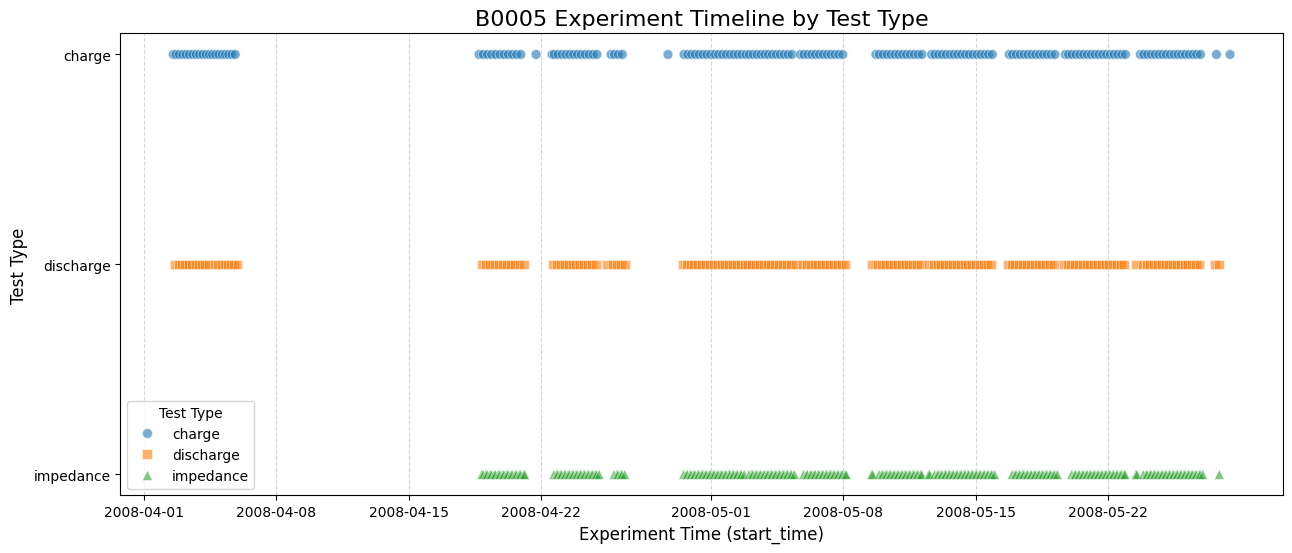

In [9]:
##### 시각화

# 1. B0005 데이터만 필터링 및 시간순 정렬 (metadata 통합본 사용)
df_b0005_meta = B0005_timeline.copy()
df_b0005_meta = df_b0005_meta.sort_values('start_time')

# 3. 시각화 (Y축: type, X축: start_time)
plt.figure(figsize=(15, 6))

# scatterplot을 활용하여 점으로 표현 (alpha로 투명도 조절하여 겹침 확인)
sns.scatterplot(data=df_b0005_meta, x='start_time', y='type', hue='type', 
                style='type', markers={'charge': 'o', 'discharge': 's', 'impedance': '^'},
                s=50, alpha=0.6)

plt.title('B0005 Experiment Timeline by Test Type', fontsize=16)
plt.xlabel('Experiment Time (start_time)', fontsize=12)
plt.ylabel('Test Type', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5) # X축(시간) 그리드 강조
plt.legend(title='Test Type')
plt.show()

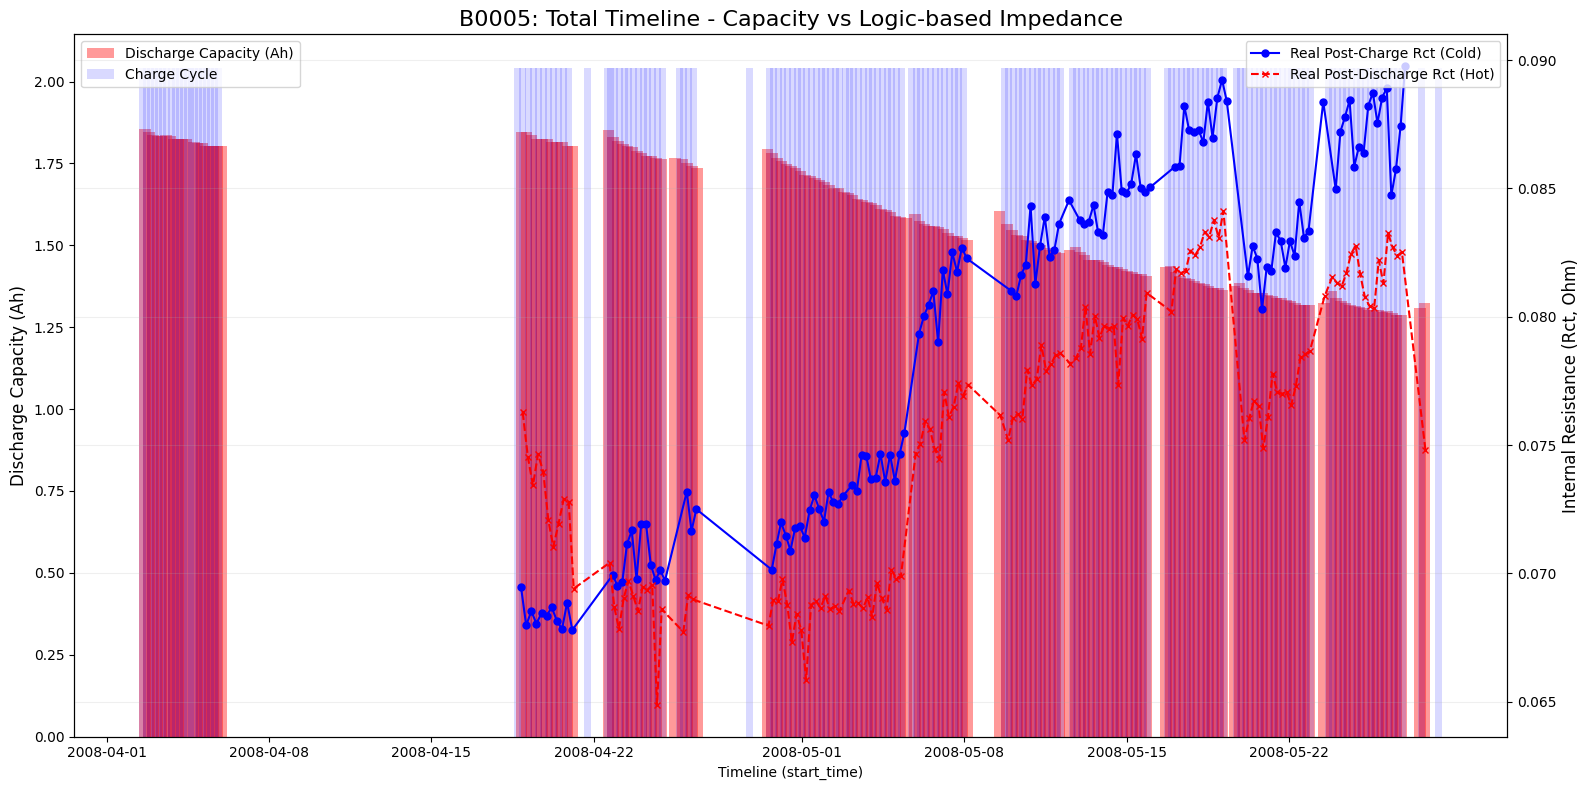

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 시각화용 요약 데이터 생성 (각 실험의 시작점 정보만 추출)
df_sum = df_total_B0005.drop_duplicates('start_time').sort_values('start_time').copy()

# 2. 로직 기반 임피던스 분리 (중요!)
df_sum['prev_type'] = df_sum['type'].shift(1)
df_imp = df_sum[df_sum['type'] == 'impedance'].copy().sort_values('start_time')
df_post_charge = df_imp[df_imp['prev_type'] == 'charge']
df_post_discharge = df_imp[df_imp['prev_type'] == 'discharge']

# 3. 타입별 데이터 분리
df_dis = df_sum[df_sum['type'] == 'discharge']
df_cha = df_sum[df_sum['type'] == 'charge']

fig, ax1 = plt.subplots(figsize=(16, 8))

# --- 왼쪽 축: Capacity (Bar) ---
# 방전 용량 (빨강)
ax1.bar(df_dis['start_time'], df_dis['Capacity'], color='red', alpha=0.4, width=0.5, label='Discharge Capacity (Ah)')
# 충전 사이클 표시 (파랑)
if not df_cha.empty:
    ax1.bar(df_cha['start_time'], [max(df_dis['Capacity'])*1.1]*len(df_cha), 
            color='blue', alpha=0.15, width=0.3, label='Charge Cycle')

ax1.set_xlabel('Timeline (start_time)')
ax1.set_ylabel('Discharge Capacity (Ah)', fontsize=12)
ax1.legend(loc='upper left')

# --- 오른쪽 축: Impedance Rct (Line) ---
ax2 = ax1.twinx()

# 진짜 충전 후 임피던스 (파란 라인)
ax2.plot(df_post_charge['start_time'], df_post_charge['Rct'], 
         color='blue', marker='o', markersize=5, linewidth=1.5, label='Real Post-Charge Rct (Cold)')

# 진짜 방전 후 임피던스 (빨간 라인)
ax2.plot(df_post_discharge['start_time'], df_post_discharge['Rct'], 
         color='red', marker='x', markersize=5, linestyle='--', linewidth=1.5, label='Real Post-Discharge Rct (Hot)')

ax2.set_ylabel('Internal Resistance (Rct, Ohm)', fontsize=12)
ax2.legend(loc='upper right')

plt.title('B0005: Total Timeline - Capacity vs Logic-based Impedance', fontsize=16)
plt.grid(True, axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

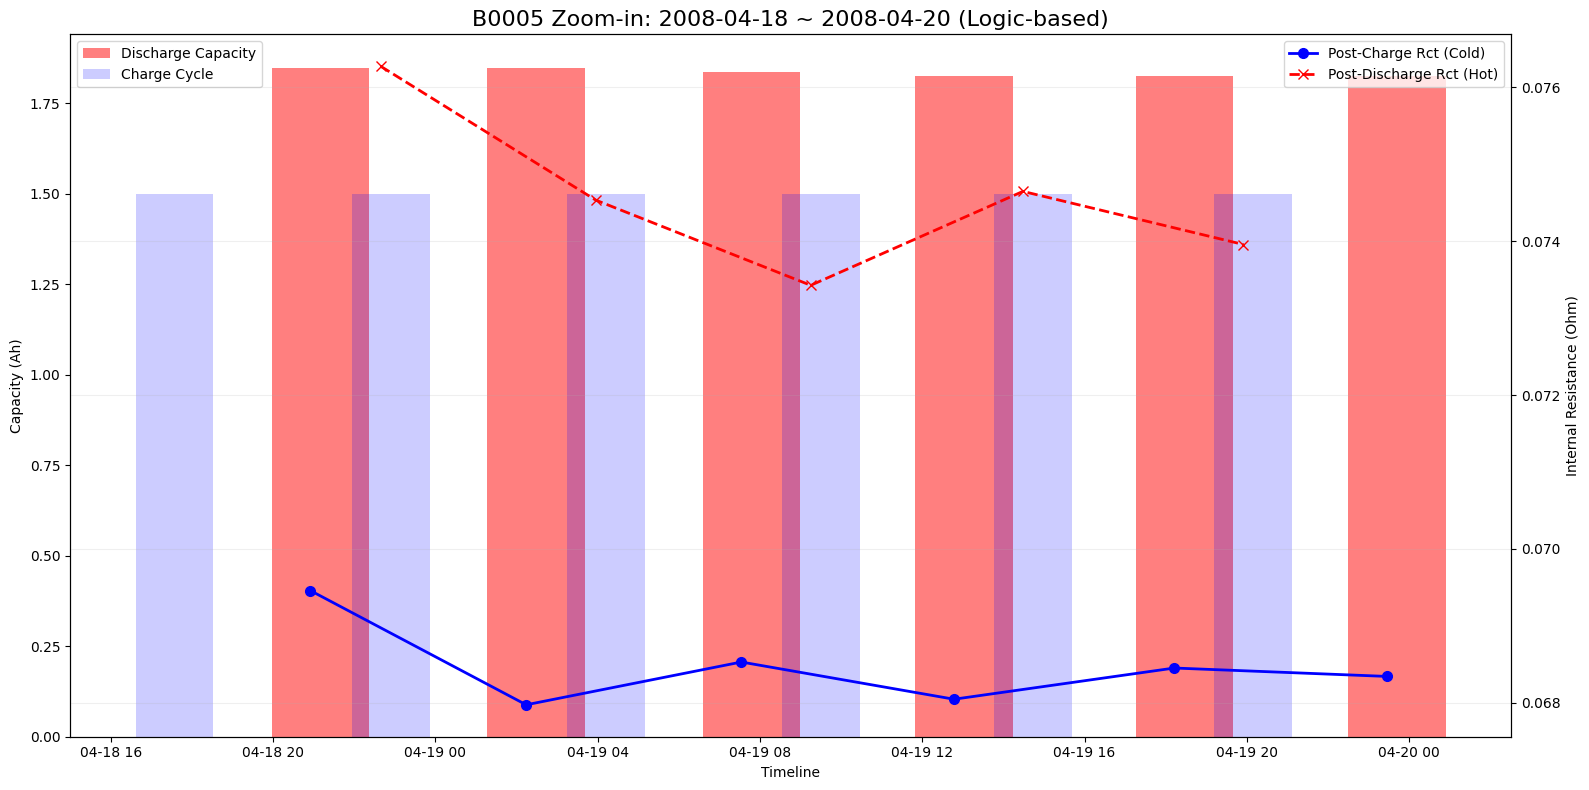

In [11]:
# --- [설정] 보고 싶은 기간 ---
start_date = '2008-04-18'
end_date   = '2008-04-20'
# ---------------------------

# 1. 요약 데이터에서 기간 필터링
mask = (df_sum['start_time'] >= start_date) & (df_sum['start_time'] <= end_date)
df_zoom = df_sum.loc[mask]

# 2. 필터링된 데이터 내에서 타입 재분할
df_z_dis = df_zoom[df_zoom['type'] == 'discharge']
df_z_cha = df_zoom[df_zoom['type'] == 'charge']
df_z_imp = df_zoom[df_zoom['type'] == 'impedance']

# 임피던스 내 로직 분리 (이미 전체에서 prev_type이 계산되어 있으므로 그대로 사용)
df_z_post_charge = df_z_imp[df_z_imp['prev_type'] == 'charge']
df_z_post_discharge = df_z_imp[df_z_imp['prev_type'] == 'discharge']

fig, ax1 = plt.subplots(figsize=(16, 8))

# --- 왼쪽 축: 막대 그래프 ---
# 확대 시 막대가 너무 얇아보이지 않게 width를 0.1 정도로 조정
ax1.bar(df_z_dis['start_time'], df_z_dis['Capacity'], color='red', alpha=0.5, width=0.1, label='Discharge Capacity')
if not df_z_cha.empty:
    ax1.bar(df_z_cha['start_time'], [1.5]*len(df_z_cha), color='blue', alpha=0.2, width=0.08, label='Charge Cycle')

ax1.set_xlabel('Timeline')
ax1.set_ylabel('Capacity (Ah)')
ax1.legend(loc='upper left')

# --- 오른쪽 축: 라인 그래프 ---
ax2 = ax1.twinx()

ax2.plot(df_z_post_charge['start_time'], df_z_post_charge['Rct'], 
         color='blue', marker='o', markersize=7, linewidth=2, label='Post-Charge Rct (Cold)')
ax2.plot(df_z_post_discharge['start_time'], df_z_post_discharge['Rct'], 
         color='red', marker='x', markersize=7, linestyle='--', linewidth=2, label='Post-Discharge Rct (Hot)')

ax2.set_ylabel('Internal Resistance (Ohm)')
ax2.legend(loc='upper right')

plt.title(f'B0005 Zoom-in: {start_date} ~ {end_date} (Logic-based)', fontsize=16)
plt.grid(True, axis='both', alpha=0.2)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

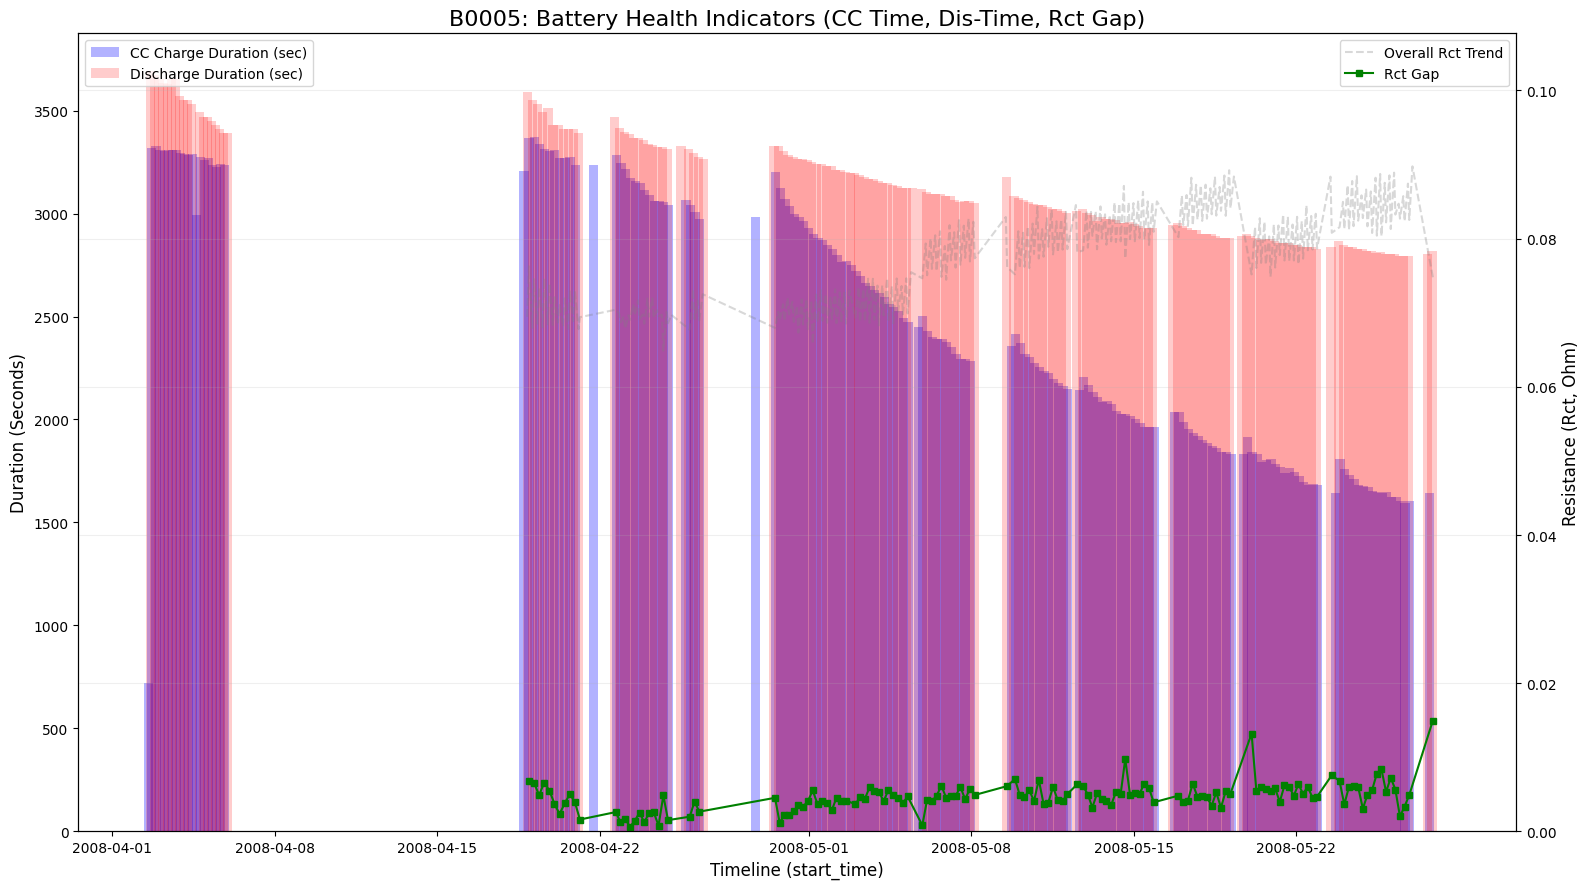

'\n    1. "용량이 줄어들면 저항이 뛴다" (Rct 트렌드의 의미)그래프 배경에 깔린 회색 지그재그 라인인 Overall Rct Trend를 보세요.의미: $R_{ct}$(전하 전달 저항)는 리튬 이온이 전극 안으로 들어갈 때 겪는 \'문턱\'입니다.\n    해석: 시간이 지날수록 이 회색 라인이 우상향하죠? 이는 배터리 내부 전극 표면에 찌꺼기(SEI 층)가 쌓여 이온이 통과하기 점점 힘들어지고 있다는 뜻입니다. \n    특히 후반부에 라인이 급격히 튀어 오르는 지점은 배터리 내부 구조가 무너지기 시작하는 \'위험 신호\'입니다.\n    2. "저항이 높으면 충전이 안 된다" (CC Time의 급감)파란색 막대(CC Charge Duration)의 높이가 시간이 갈수록 낮아지는 점에 주목하세요.\n    의미: 정전류(CC) 충전은 배터리에 에너지를 가장 많이 밀어 넣는 핵심 구간입니다.해석: 내부 저항($R_{ct}$)이 커지면, 충전을 시작하자마자 배터리 전압이 4.2V(한계치)에 너무 빨리 도달해버립니다. \n    그래서 시스템이 배터리를 보호하기 위해 충전 전류를 일찍 줄여버리게 되죠.결과: 파란 막대가 짧아진다는 것은 **"배터리가 밥(전기)을 먹는 속도가 현저히 느려졌다"**는 뜻입니다.\n    3. "충·방전 저항의 불균형" (Rct Gap의 의미)하단에 초록색 점들로 이어진 Rct Gap 라인을 보세요.\n    의미: 충전 직후의 저항과 방전 직후의 저항 사이의 차이값입니다.해석: 배터리가 건강할 때는 이 간격이 일정하게 유지됩니다. \n    하지만 그래프 후반부를 보면 초록색 점들이 위로 솟구치거나 요동치기 시작합니다.\n\n    결론: 이는 배터리가 \'가득 찼을 때\'와 \'비었을 때\'의 상태 차이가 극심해졌음을 의미하며, 화학적으로 매우 불안정해져 **폭발적인 노화(Thermal runaway 위험 등)**로 이어질 수 있는 단계임을 암시합니다.\n    '

In [12]:


# 1. 시각화용 요약 데이터 생성 (df_sum)

# 2. 파생 지표 계산 함수들
def get_duration(df_total, start_time, d_type):
    # 각 사이클의 순수 소요 시간 계산
    data = df_total[df_total['start_time'] == start_time]
    if d_type == 'charge':
        # 정전류(CC) 구간 시간 추출 (전류 1.45A 이상 유지 시간)
        cc_phase = data[data['Current_measured'] >= 1.45]
        return cc_phase['Time'].max() - cc_phase['Time'].min() if not cc_phase.empty else 0
    else:
        # 일반 방전 소요 시간
        return data['Time'].max() - data['Time'].min()

# 지표 계산 및 주입
df_sum['CC_Time'] = df_sum.apply(lambda x: get_duration(df_total_B0005, x['start_time'], 'charge') if x['type'] == 'charge' else np.nan, axis=1)
df_sum['Dis_Time'] = df_sum.apply(lambda x: get_duration(df_total_B0005, x['start_time'], 'discharge') if x['type'] == 'discharge' else np.nan, axis=1)


# 3. 임피던스 차이(Delta Rct) 계산 (시간 기반)

df_pc = df_imp[df_imp['prev_type'] == 'charge'].copy()
df_pd = df_imp[df_imp['prev_type'] == 'discharge'].copy()

df_pc = df_pc.sort_values('start_time')
df_pd = df_pd.sort_values('start_time')

df_rct_gap_all = pd.merge_asof(
    df_pd.sort_values('start_time'),
    df_pc.sort_values('start_time'),
    on='start_time',
    direction='backward',
    suffixes=('_discharge', '_charge')
)

df_rct_gap_all['Rct_gap'] = np.abs(
    df_rct_gap_all['Rct_charge'] - df_rct_gap_all['Rct_discharge']
)


# 4. 시각화
fig, ax1 = plt.subplots(figsize=(16, 9))

# --- 왼쪽 축 (Bar): 시간 지표 (Time Metrics) ---
# 정전류 충전 시간 (파란색 막대)
df_cha = df_sum[df_sum['type'] == 'charge']
ax1.bar(df_cha['start_time'], df_cha['CC_Time'], color='blue', alpha=0.3, width=0.4, label='CC Charge Duration (sec)')

# 방전 지속 시간 (빨간색 막대)
df_dis = df_sum[df_sum['type'] == 'discharge'].copy()
df_dis['Capacity_fade'] = (
    df_dis['Capacity'] / df_dis['Capacity'].iloc[0]
)

ax1.bar(df_dis['start_time'], df_dis['Dis_Time'], color='red', alpha=0.2, width=0.4, label='Discharge Duration (sec)')

ax1.set_xlabel('Timeline (start_time)', fontsize=12)
ax1.set_ylabel('Duration (Seconds)', fontsize=12)
ax1.legend(loc='upper left')

# --- 오른쪽 축 (Line): 저항 불균형 (Rct Delta) ---


# 1. Overall Rct를 위한 데이터 재생성 및 시간축 변환
df_imp_plot = df_total_B0005[df_total_B0005['type'] == 'impedance'].drop_duplicates('start_time').copy()
df_imp_plot = df_imp_plot.sort_values('start_time')
df_imp_plot['start_time'] = pd.to_datetime(df_imp_plot['start_time'])
df_rct_gap_all['start_time'] = pd.to_datetime(df_rct_gap_all['start_time'])

# 2. 오른쪽 축 설정
ax2 = ax1.twinx()

# 3. Overall Rct Trend (회색 점선) - 먼저 그려서 배경으로 깔기
ax2.plot(df_imp_plot['start_time'], df_imp_plot['Rct'], 
         color='gray', alpha=0.3, linestyle='--', label='Overall Rct Trend')

# 4. Rct Gap (초록색 실선)
ax2.plot(df_rct_gap_all['start_time'], df_rct_gap_all['Rct_gap'], 
         color='green', marker='s', markersize=4, label='Rct Gap')

# 5. Y축 범위 설정 (Rct 전체 값을 기준으로 해야 둘 다 보입니다)
ax2.set_ylabel('Resistance (Rct, Ohm)', fontsize=12)

max_rct = max(
    df_imp_plot['Rct'].max(),
    df_rct_gap_all['Rct_gap'].max()
)
ax2.set_ylim(0, max_rct * 1.2)
ax2.legend(loc='upper right')

plt.title('B0005: Battery Health Indicators (CC Time, Dis-Time, Rct Gap)', fontsize=16)
plt.grid(True, axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"""
    1. "용량이 줄어들면 저항이 뛴다" (Rct 트렌드의 의미)그래프 배경에 깔린 회색 지그재그 라인인 Overall Rct Trend를 보세요.의미: $R_{ct}$(전하 전달 저항)는 리튬 이온이 전극 안으로 들어갈 때 겪는 '문턱'입니다.
    해석: 시간이 지날수록 이 회색 라인이 우상향하죠? 이는 배터리 내부 전극 표면에 찌꺼기(SEI 층)가 쌓여 이온이 통과하기 점점 힘들어지고 있다는 뜻입니다. 
    특히 후반부에 라인이 급격히 튀어 오르는 지점은 배터리 내부 구조가 무너지기 시작하는 '위험 신호'입니다.
    2. "저항이 높으면 충전이 안 된다" (CC Time의 급감)파란색 막대(CC Charge Duration)의 높이가 시간이 갈수록 낮아지는 점에 주목하세요.
    의미: 정전류(CC) 충전은 배터리에 에너지를 가장 많이 밀어 넣는 핵심 구간입니다.해석: 내부 저항($R_{ct}$)이 커지면, 충전을 시작하자마자 배터리 전압이 4.2V(한계치)에 너무 빨리 도달해버립니다. 
    그래서 시스템이 배터리를 보호하기 위해 충전 전류를 일찍 줄여버리게 되죠.결과: 파란 막대가 짧아진다는 것은 **"배터리가 밥(전기)을 먹는 속도가 현저히 느려졌다"**는 뜻입니다.
    3. "충·방전 저항의 불균형" (Rct Gap의 의미)하단에 초록색 점들로 이어진 Rct Gap 라인을 보세요.
    의미: 충전 직후의 저항과 방전 직후의 저항 사이의 차이값입니다.해석: 배터리가 건강할 때는 이 간격이 일정하게 유지됩니다. 
    하지만 그래프 후반부를 보면 초록색 점들이 위로 솟구치거나 요동치기 시작합니다.
    
    결론: 이는 배터리가 '가득 찼을 때'와 '비었을 때'의 상태 차이가 극심해졌음을 의미하며, 화학적으로 매우 불안정해져 **폭발적인 노화(Thermal runaway 위험 등)**로 이어질 수 있는 단계임을 암시합니다.
    """

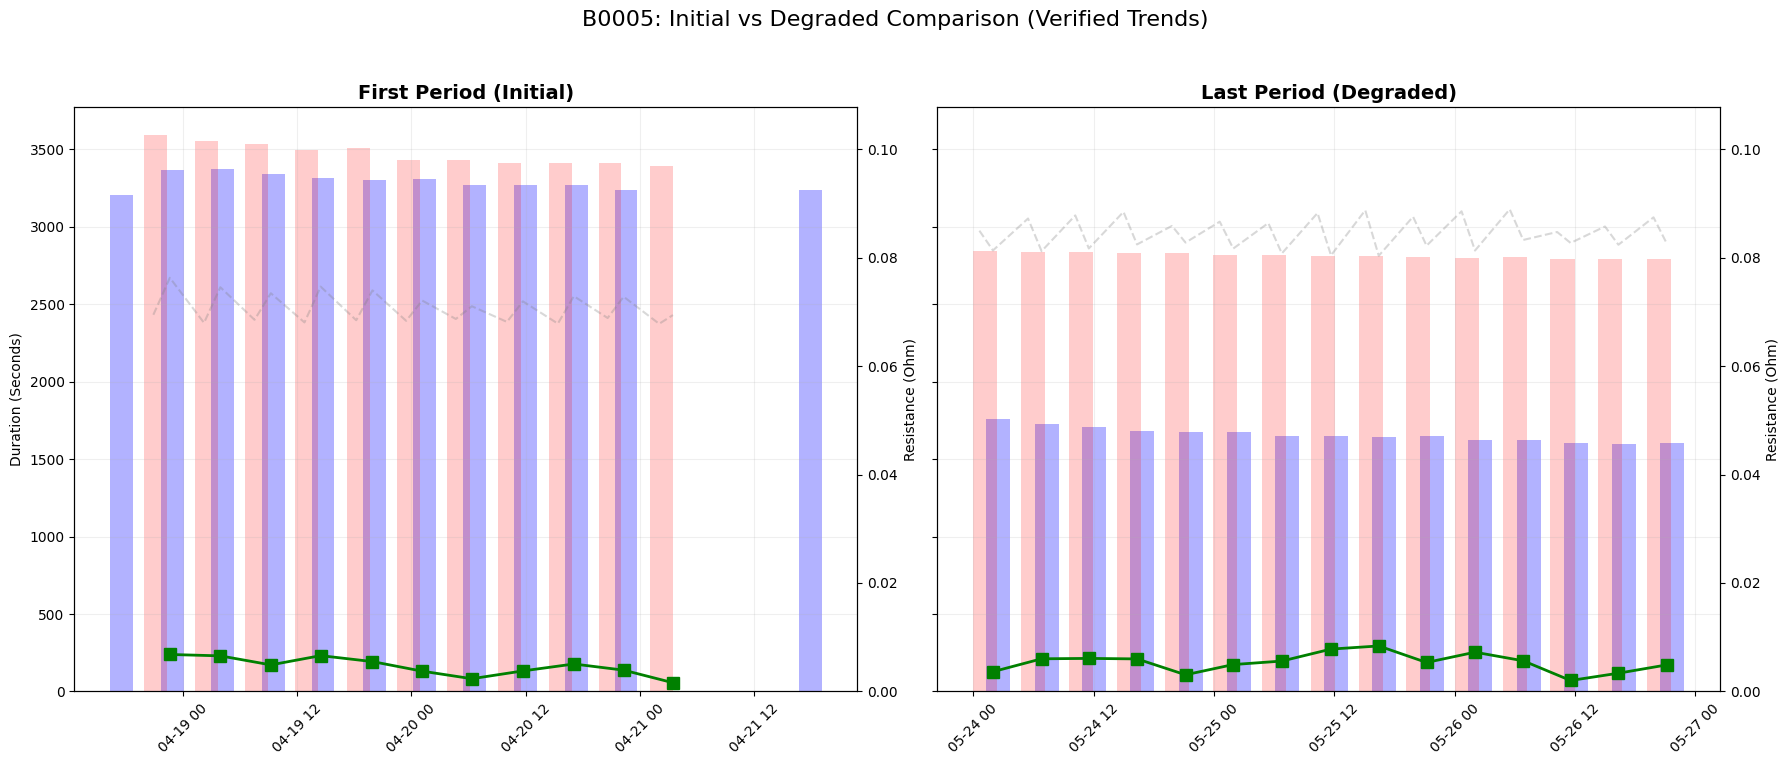

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. 구간 설정
first_period = ('2008-04-17', '2008-04-22')  # 전반부
last_period  = ('2008-05-24', '2008-05-27')  # 후반부

# 2. 요약 데이터 생성 및 기본 지표 계산

def get_duration(df_total, start_time, d_type):
    data = df_total[df_total['start_time'] == start_time]
    if d_type == 'charge':
        cc_phase = data[data['Current_measured'] >= 1.45]
        return cc_phase['Time'].max() - cc_phase['Time'].min() if not cc_phase.empty else 0
    else:
        return data['Time'].max() - data['Time'].min()


# [핵심 수정] Rct Gap (시간 기반 매칭)
########df_imp_total = df_sum[df_sum['type'] == 'impedance'].copy().sort_values('start_time')

############################df_pc = df_imp_total[df_imp_total['prev_type'] == 'charge'].copy()
############################df_pd = df_imp_total[df_imp_total['prev_type'] == 'discharge'].copy()

# [수정 1] 시간축 데이터 타입을 통일 (그래프 끊김 방지)
df_sum['start_time'] = pd.to_datetime(df_sum['start_time'])
############################df_rct_gap_all['start_time'] = pd.to_datetime(df_rct_gap_all['start_time'])

# 3. 그래프 그리기
fig, (ax_f, ax_l) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
periods = [first_period, last_period]
axes = [ax_f, ax_l]
titles = ["First Period (Initial)", "Last Period (Degraded)"]

# [수정 2] Y축 범위를 결정하기 위해 전체 Rct의 최대값 미리 파악
global_rct_max = df_sum['Rct'].max()

for ax, period, title in zip(axes, periods, titles):
    # 기간 필터링 (Timestamp 형식으로 비교)
    mask_p = (df_sum['start_time'] >= pd.to_datetime(period[0])) & (df_sum['start_time'] <= pd.to_datetime(period[1]))
    mask_g = (df_rct_gap_all['start_time'] >= pd.to_datetime(period[0])) & (df_rct_gap_all['start_time'] <= pd.to_datetime(period[1]))
    
    df_p = df_sum.loc[mask_p]
    df_g = df_rct_gap_all.loc[mask_g]
    
    # --- 왼쪽 축: 시간 지표 (Bar) ---
    df_c = df_p[df_p['type'] == 'charge']
    df_d = df_p[df_p['type'] == 'discharge']
    ax.bar(df_c['start_time'], df_c['CC_Time'], color='blue', alpha=0.3, width=0.1, label='CC Charge')
    ax.bar(df_d['start_time'], df_d['Dis_Time'], color='red', alpha=0.2, width=0.1, label='Discharge')
    
    # --- 오른쪽 축: 저항 지표 (Line) ---
    ax_tw = ax.twinx()
    
    # [수정 3] Overall Rct Trend (회색 선) - 배경으로 먼저 그리기
    df_i = df_p[df_p['type'] == 'impedance']
    ax_tw.plot(df_i['start_time'], df_i['Rct'], color='gray', alpha=0.3, linestyle='--', label='Overall Rct')
    
    # 1:1 매칭된 Gap 데이터 시각화 (초록색 점/선)
    if 'df_g' in locals() and not df_g.empty:
        ax_tw.plot(df_g['start_time'], df_g['Rct_gap'], color='green', marker='s', 
                   markersize=8, linewidth=2, label='Rct Gap', zorder=5)
    
    # [수정 4] Y축 범위를 Rct 전체 트렌드에 맞춤 (그래야 회색 선이 보임)
    # 만약 Gap을 더 강조하고 싶다면 global_rct_max 대신 특정 배수를 사용하세요.
    ax_tw.set_ylim(0, global_rct_max * 1.2)
    
    # 포맷팅
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    if ax == ax_f:
        ax.set_ylabel('Duration (Seconds)')
    
    # [수정 5] 오른쪽 축 라벨은 마지막 서브플롯에만 표시하거나 양쪽 다 표시
    ax_tw.set_ylabel('Resistance (Ohm)')
    
    ax.grid(True, alpha=0.2)

plt.suptitle('B0005: Initial vs Degraded Comparison (Verified Trends)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

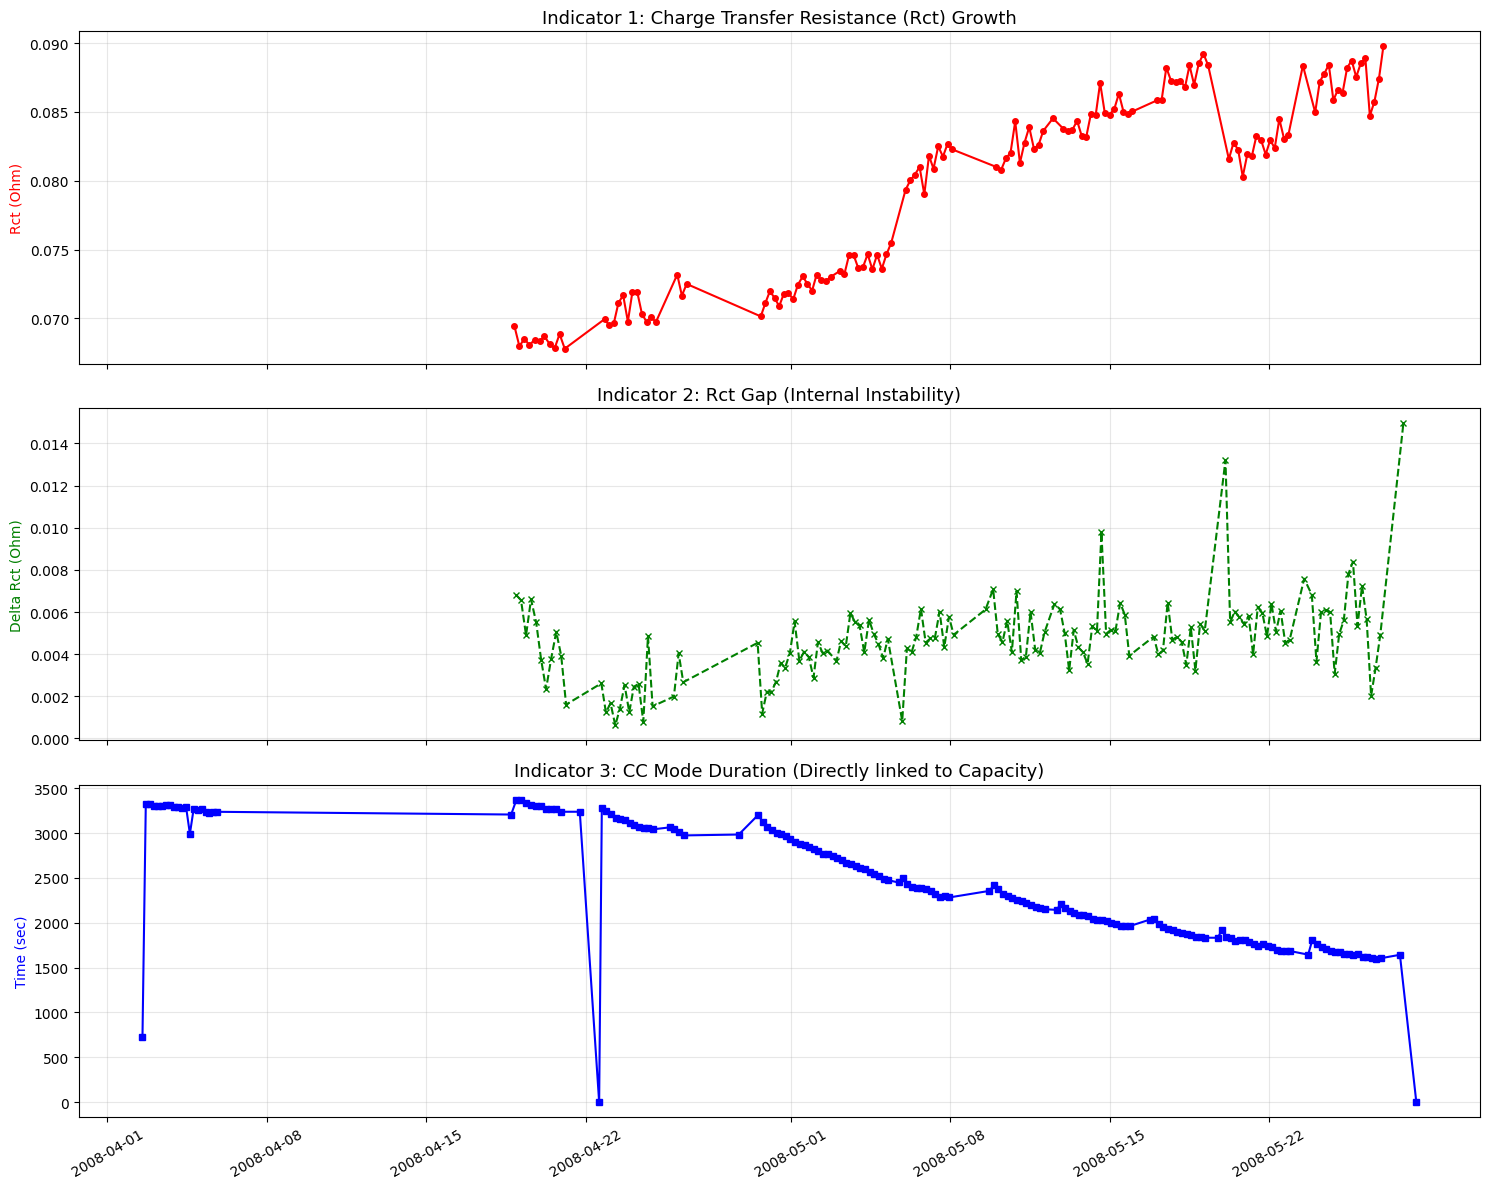

In [14]:

# 1. 시각화용 요약 데이터 <df=sum>

# 2. 지표 추출 함수: CC Time (정전류 충전 시간) 계산
# 충전 전류가 약 1.5A로 유지되는 시간을 각 충전 사이클마다 계산
def get_cc_time(df_total, start_time):
    # 해당 사이클의 충전 데이터만 필터링
    c_data = df_total[df_total['start_time'] == start_time]
    # 전류가 1.5A 근처(예: 1.45A 이상)인 데이터의 시간차 계산
    cc_phase = c_data[c_data['Current_measured'] >= 1.45]
    if not cc_phase.empty:
        return cc_phase['Time'].max() - cc_phase['Time'].min()
    return 0



# 3. 타입별 데이터 분할
df_pc_rct = df_imp[df_imp['prev_type'] == 'charge']      # Post-Charge Rct
df_pd_rct = df_imp[df_imp['prev_type'] == 'discharge']   # Post-Discharge Rct

# 4. 시각화 (3단 구성)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# (A) Post-Charge Rct (가장 민감한 노화 지표)
ax1.plot(df_pc_rct['start_time'], df_pc_rct['Rct'], 'r-o', markersize=4, label='Post-Charge Rct')
ax1.set_ylabel('Rct (Ohm)', color='red')
ax1.set_title('Indicator 1: Charge Transfer Resistance (Rct) Growth', fontsize=13)
ax1.grid(True, alpha=0.3)

# (B) 저항 차이 (충전후 vs 방전후 편차 - 내부 불안정성)
ax2.plot(df_rct_gap_all['start_time'], df_rct_gap_all['Rct_gap'], 'g--x', markersize=4, label='|PostCharge - PostDischarge|')

ax2.set_ylabel('Delta Rct (Ohm)', color='green')
ax2.set_title('Indicator 2: Rct Gap (Internal Instability)', fontsize=13)
ax2.grid(True, alpha=0.3)

# (C) 정전류(CC) 충전 시간 (운용 성능 지표)
df_cc = df_sum[df_sum['type'] == 'charge'].dropna(subset=['CC_Time'])
ax3.plot(df_cc['start_time'], df_cc['CC_Time'], 'b-s', markersize=4, label='CC Charging Time')
ax3.set_ylabel('Time (sec)', color='blue')
ax3.set_title('Indicator 3: CC Mode Duration (Directly linked to Capacity)', fontsize=13)
ax3.grid(True, alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

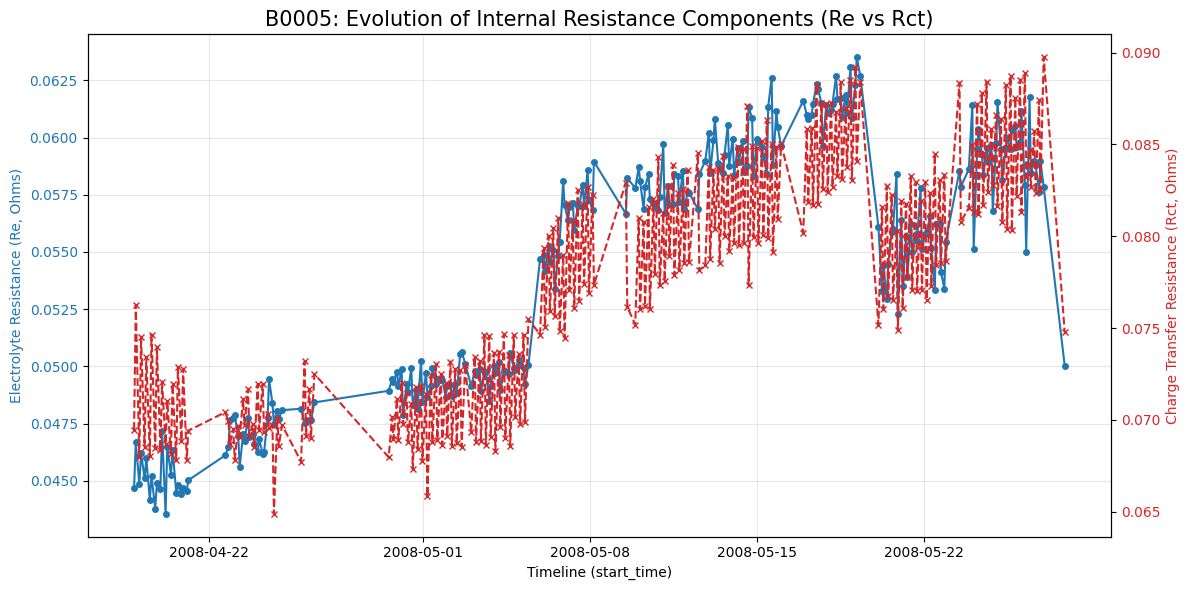

In [15]:
import matplotlib.pyplot as plt

# 1. 임피던스 데이터만 추출하여 시간순 정렬
df_imp_trend = df_total_B0005[df_total_B0005['type'] == 'impedance'].drop_duplicates('start_time').sort_values('start_time')

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- 첫 번째 축: Re (오믹 저항) ---
color_re = 'tab:blue'
ax1.set_xlabel('Timeline (start_time)')
ax1.set_ylabel('Electrolyte Resistance (Re, Ohms)', color=color_re)
ax1.plot(df_imp_trend['start_time'], df_imp_trend['Re'], color=color_re, marker='o', markersize=4, label='Re (Electrolyte)')
ax1.tick_params(axis='y', labelcolor=color_re)

# --- 두 번째 축: Rct (전하 전달 저항) ---
ax2 = ax1.twinx() # x축 공유
color_rct = 'tab:red'
ax2.set_ylabel('Charge Transfer Resistance (Rct, Ohms)', color=color_rct)
ax2.plot(df_imp_trend['start_time'], df_imp_trend['Rct'], color=color_rct, marker='x', markersize=4, linestyle='--', label='Rct (Surface)')
ax2.tick_params(axis='y', labelcolor=color_rct)

# 저항증가율???
df_imp_trend['Rct_norm'] = df_imp_trend['Rct'] / df_imp_trend['Rct'].iloc[0]

# --- 그래프 꾸미기 ---
plt.title('B0005: Evolution of Internal Resistance Components (Re vs Rct)', fontsize=15)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.xticks(rotation=30)
plt.show()

In [ ]:
print(df_sum.columns)

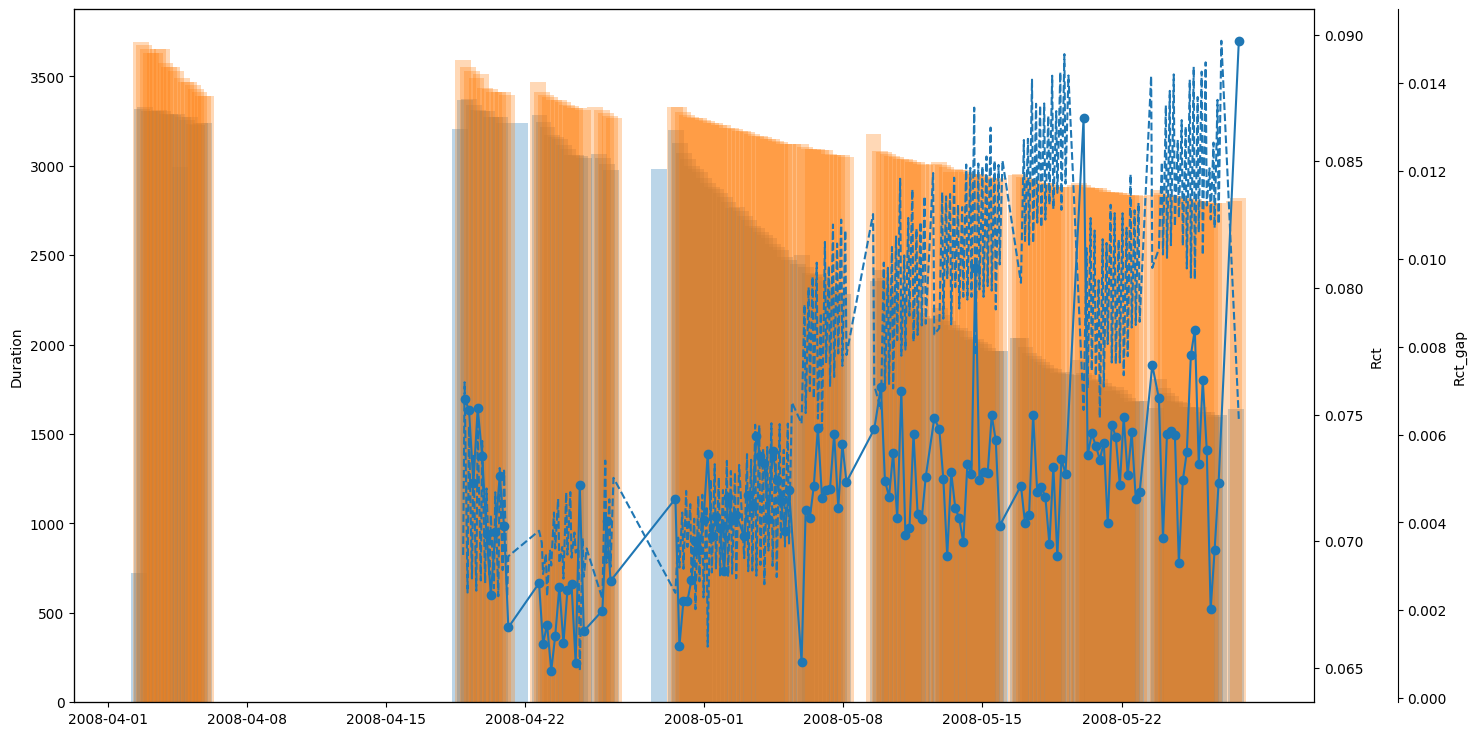

In [16]:
### 그래프 1 (시간 + Rct_gap)

fig, ax1 = plt.subplots(figsize=(16, 9))

# --- 시간 ---
ax1.bar(df_cha['start_time'], df_cha['CC_Time'], alpha=0.3)
ax1.bar(df_dis['start_time'], df_dis['Dis_Time'], alpha=0.3)
ax1.set_ylabel('Duration')

# --- Rct ---
ax2 = ax1.twinx()
ax2.plot(df_imp_plot['start_time'], df_imp_plot['Rct'], linestyle='--')
ax2.set_ylabel('Rct')

# --- Rct_gap 전용 축 ---
ax3 = ax1.twinx()

# 축 위치 이동 (핵심)
ax3.spines["right"].set_position(("outward", 60))

ax3.plot(df_rct_gap_all['start_time'], df_rct_gap_all['Rct_gap'], marker='o')
ax3.set_ylabel('Rct_gap')

plt.show()

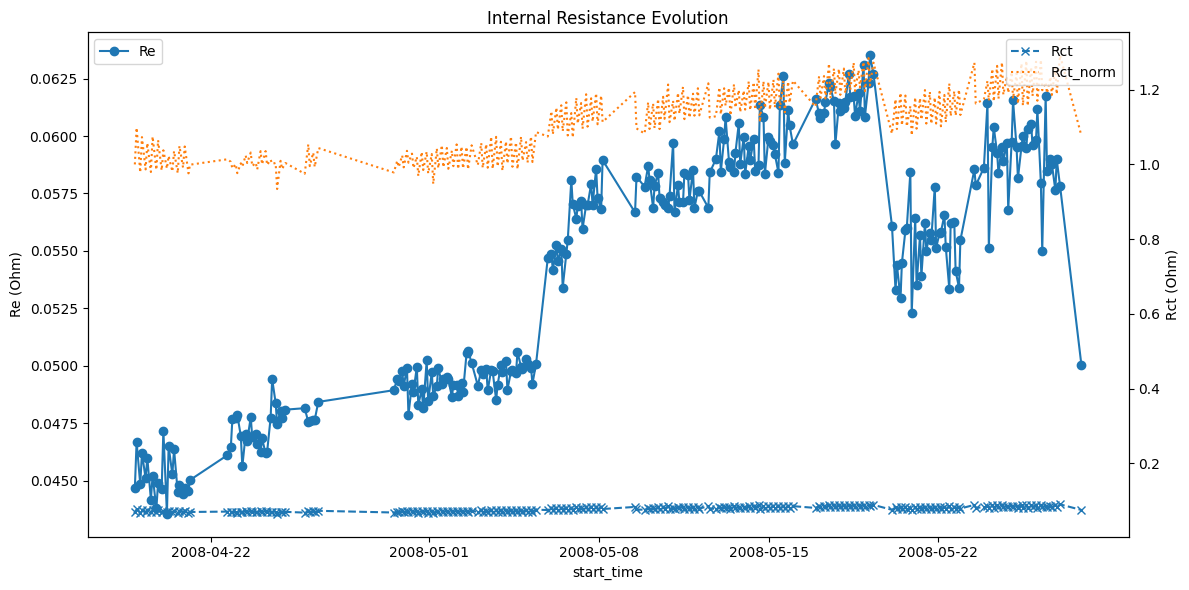

In [17]:
##### 그래프 2 (Re / Rct / Rct_norm)
df_imp_trend = df_total_B0005[
    df_total_B0005['type'] == 'impedance'
].drop_duplicates('start_time').sort_values('start_time')

# 정규화
df_imp_trend['Rct_norm'] = df_imp_trend['Rct'] / df_imp_trend['Rct'].iloc[0]

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Re ---
ax1.plot(
    df_imp_trend['start_time'],
    df_imp_trend['Re'],
    marker='o',
    label='Re'
)
ax1.set_ylabel('Re (Ohm)')

# --- Rct ---
ax2 = ax1.twinx()
ax2.plot(
    df_imp_trend['start_time'],
    df_imp_trend['Rct'],
    linestyle='--',
    marker='x',
    label='Rct'
)
ax2.set_ylabel('Rct (Ohm)')

# --- Rct_norm (같이 그리기) ---
ax2.plot(
    df_imp_trend['start_time'],
    df_imp_trend['Rct_norm'],
    linestyle=':',
    label='Rct_norm'
)

ax1.set_xlabel('start_time')
plt.title('Internal Resistance Evolution')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



총 임피던스 개수: 278
충전 후(Post-Charge) 개수: 136
방전 후(Post-Discharge) 개수: 141


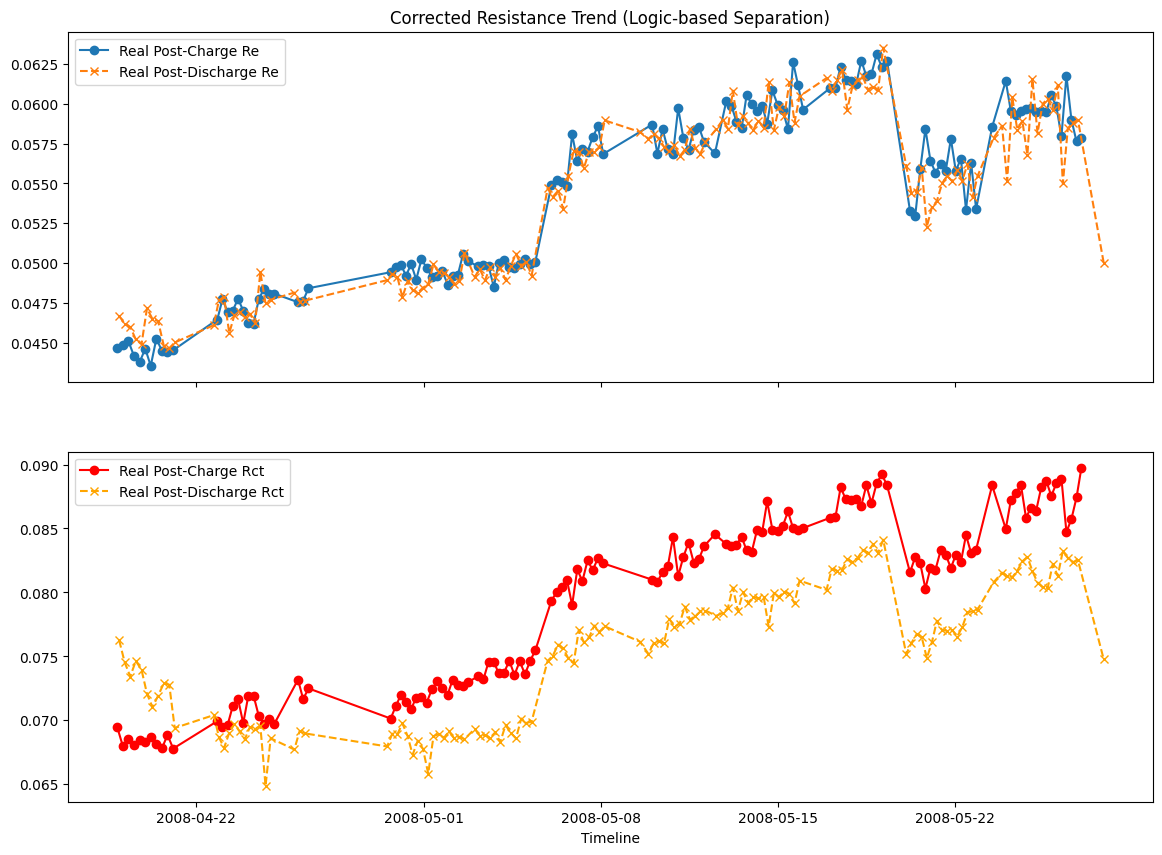

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 모든 실험 타입을 시간순으로 정렬 (B0005 전체 데이터 기준)
# 시계열 데이터를 파일 단위로 요약한 메타데이터(df_total_B0005 생성 전의 원본 리스트 형태)가 필요합니다.
# 여기서는 df_total_B0005에서 중복되지 않는 실험 시작점들만 뽑아서 확인합니다.
timeline = df_total_B0005.drop_duplicates('start_time').sort_values('start_time').copy()

# 2. 직전 실험 타입(Prev_Type) 컬럼 생성
timeline['prev_type'] = timeline['type'].shift(1)

# 3. 임피던스 데이터만 필터링한 뒤, 직전 타입에 따라 분류
impedance_only = timeline[timeline['type'] == 'impedance'].copy()

# 'charge' 직후에 온 임피던스 -> 진짜 Post-Charge
df_real_post_charge = impedance_only[impedance_only['prev_type'] == 'charge']

# 'discharge' 직후에 온 임피던스 -> 진짜 Post-Discharge
df_real_post_discharge = impedance_only[impedance_only['prev_type'] == 'discharge']

# 4. 확인 출력
print(f"총 임피던스 개수: {len(impedance_only)}")
print(f"충전 후(Post-Charge) 개수: {len(df_real_post_charge)}")
print(f"방전 후(Post-Discharge) 개수: {len(df_real_post_discharge)}")

# --- 이제 이 데이터로 다시 시각화 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Re 그래프
ax1.plot(df_real_post_charge['start_time'], df_real_post_charge['Re'], 'o-', label='Real Post-Charge Re')
ax1.plot(df_real_post_discharge['start_time'], df_real_post_discharge['Re'], 'x--', label='Real Post-Discharge Re')
ax1.legend(); ax1.set_title("Corrected Resistance Trend (Logic-based Separation)")

# Rct 그래프
ax2.plot(df_real_post_charge['start_time'], df_real_post_charge['Rct'], 'o-', color='red', label='Real Post-Charge Rct')
ax2.plot(df_real_post_discharge['start_time'], df_real_post_discharge['Rct'], 'x--', color='orange', label='Real Post-Discharge Rct')
ax2.legend(); ax2.set_xlabel("Timeline")

plt.show()

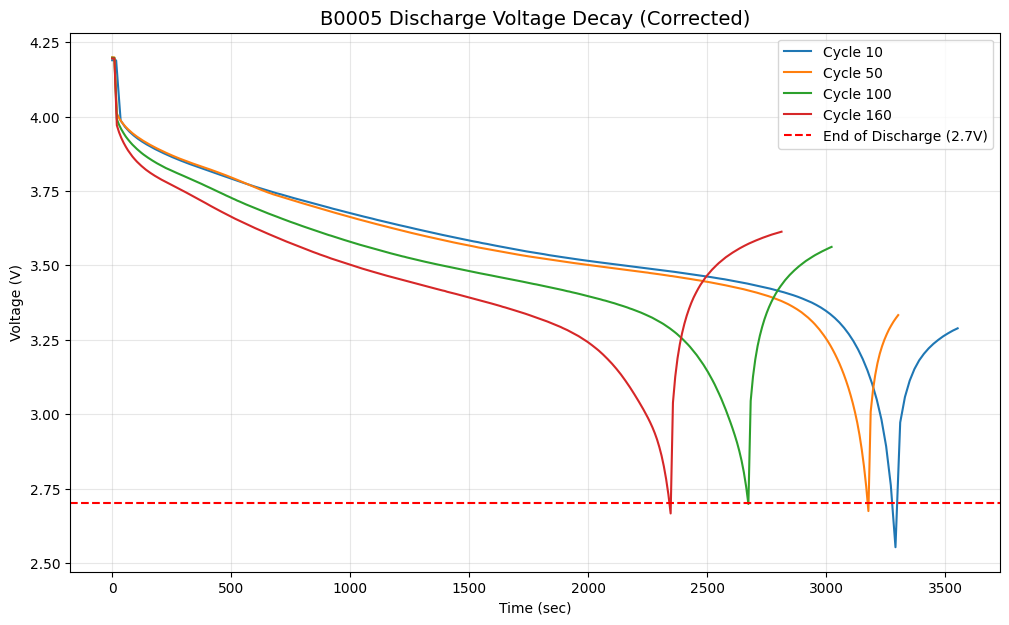

In [19]:
##### 1. 방전 전압 강하 (Voltage Drop) 곡선
# 배터리가 노화될수록 저항 때문에 초기 전압이 툭 떨어지고(IR Drop), 전압이 종지 전압(2.7V)까지 도달하는 속도가 빨라집니다.

def plot_discharge_curves(df, cycles_to_plot=[10, 50, 100, 160]):
    plt.figure(figsize=(12, 7))
    
    # 방전 데이터만 미리 필터링
    discharge_df = df[df['type'] == 'discharge']
    
    for cyc in cycles_to_plot:
        # 1. 수정: 'cycle' 대신 통합 시 만든 'cycle_in_type' 사용
        cycle_data = discharge_df[discharge_df['cycle_in_type'] == cyc]
        
        if not cycle_data.empty:
            # 2. 수정: 'start_time' 대신 시계열 내부의 'Time' 컬럼 사용
            # Time이 0부터 시작하지 않을 경우를 대비해 min을 빼줌
            relative_time = cycle_data['Time'] - cycle_data['Time'].min()
            
            # 3. 정렬 확인: 시계열 순서대로 그려지도록 정렬
            cycle_data = cycle_data.sort_values('Time')
            
            plt.plot(relative_time, cycle_data['Voltage_measured'], label=f'Cycle {cyc}')
    
    plt.axhline(y=2.7, color='r', linestyle='--', label='End of Discharge (2.7V)')
    plt.title('B0005 Discharge Voltage Decay (Corrected)', fontsize=14)
    plt.xlabel('Time (sec)')
    plt.ylabel('Voltage (V)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
plot_discharge_curves(df_total_B0005)

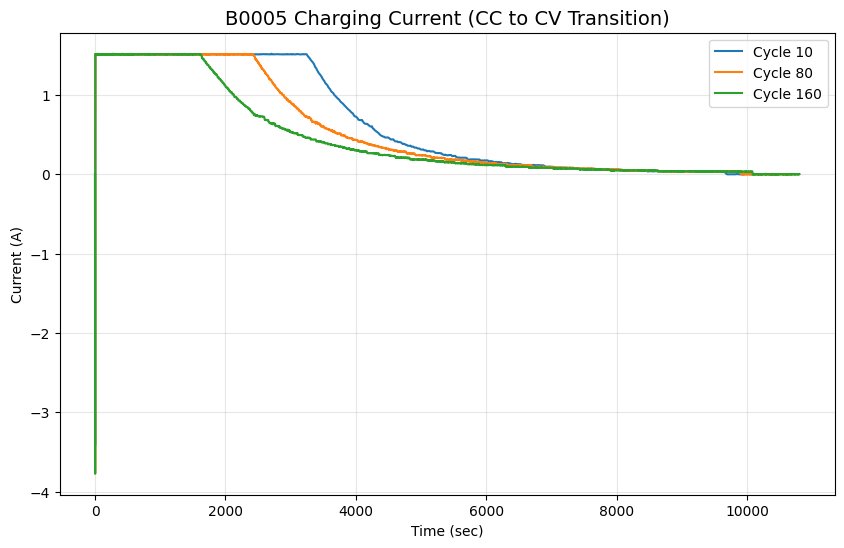

In [20]:
##### 2. 방전 전압 강하 (Voltage Drop) 곡선
# 배터리가 노화될수록 저항 때문에 초기 전압이 툭 떨어지고(IR Drop), 전압이 종지 전압(2.7V)까지 도달하는 속도가 빨라집니다.
#충전 전류 곡선 (CC-CV 전환 확인)
#배터리가 노화될수록 저항 증가로 인해 일정한 전류로 충전하는 CC 구간이 짧아지고, 전류를 줄이며 충전하는 CV 구간이 길어지는 현상을 시각화합니다.

def plot_cc_cv_transition(df, cycles_to_plot=[10, 80, 160]):
    plt.figure(figsize=(10, 6))
    
    # 충전 데이터만 필터링
    charge_df = df[df['type'] == 'charge']
    
    for cyc in cycles_to_plot:
        # 통합 시 생성한 cycle_in_type 사용
        cycle_data = charge_df[charge_df['cycle_in_type'] == cyc]
        
        if not cycle_data.empty:
            # 시간순 정렬 및 상대 시간 계산
            cycle_data = cycle_data.sort_values('Time')
            relative_time = cycle_data['Time'] - cycle_data['Time'].min()
            
            # 충전 시 전류 측정값 (Current_measured)
            plt.plot(relative_time, cycle_data['Current_measured'], label=f'Cycle {cyc}')
    
    plt.title('B0005 Charging Current (CC to CV Transition)', fontsize=14)
    plt.xlabel('Time (sec)')
    plt.ylabel('Current (A)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
plot_cc_cv_transition(df_total_B0005)

In [21]:
# 임피던스 데이터 한 줄만 출력해서 컬럼명과 값의 형태 확인
print(df_total_B0005[df_total_B0005['type'] == 'impedance'].iloc[0])

Voltage_measured                                                  NaN
Current_measured                                                  NaN
Temperature_measured                                              NaN
Current_charge                                                    NaN
Voltage_charge                                                    NaN
Time                                                              NaN
type                                                        impedance
start_time                                        2008-04-18 20:55:29
ambient_temperature                                                24
battery_id                                                      B0005
test_id                                                            40
uid                                                              5161
filename                                                    05161.csv
Capacity                                                          NaN
Re                  

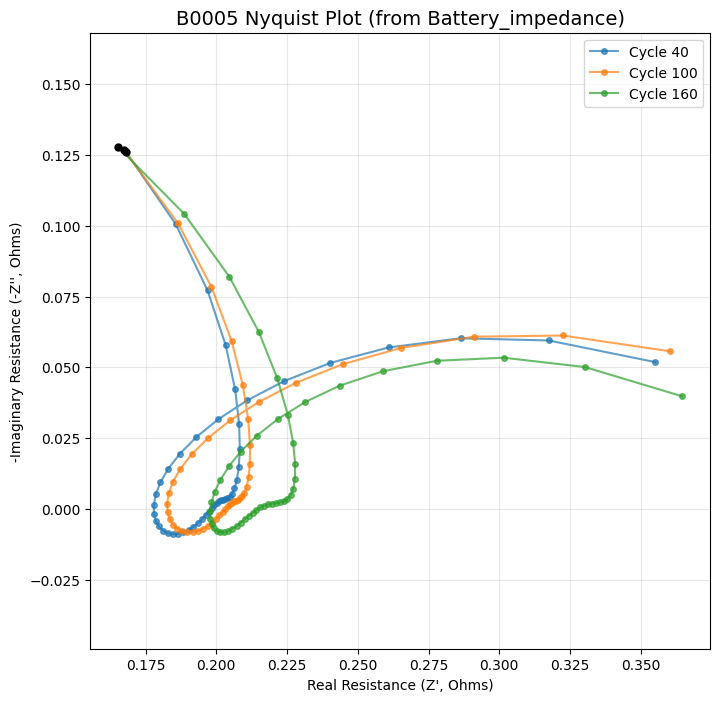

In [22]:
##### 3. 나이퀴스트 선도 (Nyquist Plot)
# 임피던스 데이터의 정수입니다. X축을 실수부($Re$), Y축을 허수부($-Im$)로 그리면 반원이 나타납니다. 배터리가 늙을수록 이 반원이 오른쪽으로 밀려나고 크기가 커집니다.

import matplotlib.pyplot as plt

def plot_nyquist(df, cycles_to_plot=[40, 100, 160]):
    plt.figure(figsize=(8, 8))
    
    # 임피던스 데이터만 필터링
    imp_df = df[df['type'] == 'impedance']
    
    for cyc in cycles_to_plot:
        # 해당 순번의 임피던스 데이터 추출
        cycle_data = imp_df[imp_df['cycle_in_type'] == cyc]
        
        if not cycle_data.empty:
            # Battery_impedance 컬럼이 복소수(complex) 타입인 경우 실수/허수 추출
            # 만약 데이터가 문자열 형태라면 .apply(complex)를 먼저 해줘야 할 수도 있습니다.
            z = cycle_data['Battery_impedance']
            
            real = z.apply(lambda x: x.real if hasattr(x, 'real') else ast.literal_eval(x).real)
            imag = z.apply(lambda x: x.imag if hasattr(x, 'imag') else ast.literal_eval(x).imag)
            
            # 나이퀴스트 선도: X축(실수), Y축(-허수)
            plt.plot(real, -imag, marker='o', markersize=4, alpha=0.7, label=f'Cycle {cyc}')
            
            # 시작점(고주파) 강조
            plt.scatter(real.iloc[0], -imag.iloc[0], color='black', s=25, zorder=5)
    
    plt.title('B0005 Nyquist Plot (from Battery_impedance)', fontsize=14)
    plt.xlabel('Real Resistance (Z\', Ohms)')
    plt.ylabel('-Imaginary Resistance (-Z\'\', Ohms)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 비율 1:1 유지
    plt.axis('equal') 
    plt.show()

# 실행
plot_nyquist(df_total_B0005)

In [23]:
df_features = df_total_B0005[df_total_B0005['type'] == 'discharge'][
    ['discharge_cycle', 'start_time', 'Capacity']
].drop_duplicates()

# Rct (가장 가까운 impedance 매칭 필요)
df_rct = df_imp_trend[['start_time', 'Rct']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rct.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# CC Time
df_cc = df_sum[df_sum['type'] == 'charge'][['start_time', 'CC_Time']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_cc.sort_values('start_time'),
    on='start_time',
    direction='backward'
)

# RUL
df_rul = df_total_B0005[['start_time', 'RUL']].drop_duplicates()

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rul.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# 배터리별type별 나눠서 12개 -> 이를 type별로 합침 -> 이후 이 것들의 흐름을 비교 또는 합쳐서 분석하기

# 배터리별type별 12개를 나눠서 csv파일에 meta 조인하기

In [ ]:
# 'B0005', 'B0006', 'B0007', 'B0018' 배터리 대상으로 충전 / 방전 / 임피던스별 data 구성하기
# SOH EOL RUL cycle 파생

# 대상 배터리 ID 리스트
target_battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']

# 데이터 저장할 폴더 경로
data_folder = "../../dataset/data"

# 데이터를 쌓아두기 위한 저장소(Dictionary) 생성
collected_data = {}


### 각 배터리별 EOL 사이클 번호를 먼저 파악 (RUL 계산용)
# SOH 80% 기준을 찾기 위해 메타데이터(df)에서 미리 계산
eol_dict = {}
for b_id in target_battery_ids:
    b_meta = df[(df['battery_id'] == b_id) & (df['type'] == 'discharge')].copy()
    if not b_meta.empty:
        initial_cap = b_meta['Capacity'].iloc[0] # 첫 번째 방전 용량
        # SOH 80% 이하인 첫 번째 행의 인덱스(순번) 찾기
        eol_idx = np.where((b_meta['Capacity'] / initial_cap) * 100 <= 80)[0]
        eol_dict[b_id] = eol_idx[0] + 1 if len(eol_idx) > 0 else np.nan

for battery_id in target_battery_ids:
    # 시간순 정렬 (매칭 오류 방지)
    filtered_df = df[df['battery_id'] == battery_id].sort_values('start_time')
    cycle_counters = {'charge': 1, 'discharge': 1, 'impedance': 1}
    
    # 기준 용량 정의 (해당 배터리의 첫 번째 방전 용량)
    dis_rows = filtered_df[filtered_df['type'] == 'discharge']
    first_cap = dis_rows['Capacity'].iloc[0] if not dis_rows.empty else None

    for _, row in filtered_df.iterrows():
        file_path = os.path.join(data_folder, row['filename'])

        if os.path.exists(file_path):
            temp_df = pd.read_csv(file_path)
            d_type = row['type']
            current_cycle = cycle_counters[d_type]

            # --- [1단계: 파생 변수 로직 정의] ---
            # SOH 정의: 오직 discharge 타입일 때만 해당 사이클의 용량으로 계산
            if d_type == 'discharge' and first_cap and pd.notnull(row['Capacity']):
                soh_val = (row['Capacity'] / first_cap) * 100
            else:
                soh_val = np.nan # 다른 타입은 우선 NaN 처리
            
            # EOL 정의: 미리 계산된 eol_dict 이용
            eol_val = eol_dict.get(battery_id)
            
            # RUL 정의: (사망 사이클 - 현재 사이클)
            rul_val = (eol_val - current_cycle) if pd.notnull(eol_val) else np.nan
            if pd.notnull(rul_val): rul_val = max(0, rul_val)

            # --- [2단계: 데이터프레임 열 추가] ---
            temp_df['start_time'] = row['start_time']
            temp_df['battery_id'] = battery_id
            temp_df['type'] = d_type
            temp_df['ambient_temperature'] = row['ambient_temperature']
            
            temp_df['cycle'] = current_cycle
            temp_df['SOH'] = soh_val  # 정의된 값 주입
            temp_df['EOL_cycle'] = eol_val
            temp_df['RUL'] = rul_val

            # 타입별 특화 데이터 추가
            if d_type == 'discharge':
                temp_df['Capacity'] = row['Capacity']
            elif d_type == 'impedance':
                temp_df['Re'] = row['Re']
                temp_df['Rct'] = row['Rct']

            # 카운터 증가 및 저장
            cycle_counters[d_type] += 1
            key = f"df_{d_type}_{battery_id}"
            if key not in collected_data:
                collected_data[key] = []
            collected_data[key].append(temp_df)

# --- [3단계: 데이터 통합 및 결측치 전파] ---
for key, df_list in collected_data.items():
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # SOH 전파: discharge 파일들 사이의 간극(charge, impedance 등)을 메워줌
    # 단, 사용자님이 'discharge에만' 있길 원하신다면 이 섹션을 제외하면 됩니다.
    # 만약 모든 행에 SOH가 필요하다면 아래 ffill/bfill을 유지하세요.
    if 'SOH' in combined_df.columns:
        combined_df['SOH'] = combined_df['SOH'].ffill()
        combined_df['SOH'] = combined_df['SOH'].bfill()
    
    globals()[key] = combined_df
    print(f"✅ {key} 생성 완료 | 파일 {len(df_list)}개 통합 | 크기: {combined_df.shape} | SOH 결측치: {combined_df['SOH'].isnull().sum()} | cycle/SOH/EOL/RUL 파생 완료")


# 배터리 4개를 모두 합침


In [ ]:
import pandas as pd

battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']
types = ['charge', 'discharge', 'impedance']

# 결과물을 담을 딕셔너리 (각 타입별 리스트)
collected_data = {t: [] for t in types}

for b_id in battery_ids:
    for t in types:
        # globals()에서 변수명(예: df_charge_B0005)을 찾아 가져오기
        var_name = f"df_{t}_{b_id}"
        
        if var_name in globals():
            temp_df = globals()[var_name].copy()
            temp_df['battery_id'] = b_id  # 배터리 식별자 추가
            temp_df['type'] = t           # 공정 타입 추가 (나중에 합칠 때 대비)
            collected_data[t].append(temp_df)

# 3개의 통합 데이터프레임 생성
df_battery_charge = pd.concat(collected_data['charge'], ignore_index=True)
df_battery_discharge = pd.concat(collected_data['discharge'], ignore_index=True)
df_battery_impedance = pd.concat(collected_data['impedance'], ignore_index=True)

# 결과 확인
print(f"✅ df_battery_charge 생성 완료 (행: {len(df_battery_charge)})")
print(f"✅ df_battery_discharge 생성 완료 (행: {len(df_battery_discharge)})")
print(f"✅ df_battery_impedance 생성 완료 (행: {len(df_battery_impedance)})")

# 3가지 EDA

In [ ]:
# 1. 요약 함수 (기존과 동일)
def summarize_with_start_time(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'cycle' in num_cols: num_cols.remove('cycle')
    agg_rules = {col: 'mean' for col in num_cols}
    if 'start_time' in df.columns:
        agg_rules['start_time'] = 'first' 
    return df.groupby(['battery_id', 'cycle']).agg(agg_rules).reset_index()

dis_summary = summarize_with_start_time(df_battery_discharge)
cha_summary = summarize_with_start_time(df_battery_charge)
imp_summary = summarize_with_start_time(df_battery_impedance)

# 2. 접두어 추가 (기존과 동일)
dis_summary = dis_summary.rename(columns=lambda x: f'dis_{x}' if x not in ['battery_id', 'cycle'] else x)
cha_summary = cha_summary.rename(columns=lambda x: f'cha_{x}' if x not in ['battery_id', 'cycle'] else x)
imp_summary = imp_summary.rename(columns=lambda x: f'imp_{x}' if x not in ['battery_id', 'cycle'] else x)

# 3. 통합 (Outer Join 유지)
all_battery_df = pd.merge(cha_summary, dis_summary, on=['battery_id', 'cycle'], how='outer')
all_battery_df = pd.merge(all_battery_df, imp_summary, on=['battery_id', 'cycle'], how='outer')

# 4. [수정] 실제 데이터가 존재하는 행만 남기기
# 조인 과정에서 특정 배터리의 최대 사이클을 초과하여 생성된 빈 행들을 제거합니다.
# 방전 용량(dis_Capacity)이나 시작 시간 중 하나라도 있는 행만 유효하다고 판단합니다.
all_battery_df = all_battery_df.dropna(subset=['dis_start_time', 'cha_start_time'], how='all')

# 5. [수정] 정렬 기준 강화
# dis_start_time이 없는 경우(임피던스만 있는 사이클 등)를 위해 cha_start_time과 혼용하여 정렬
all_battery_df['sort_key'] = all_battery_df['dis_start_time'].fillna(all_battery_df['cha_start_time'])
all_battery_df = all_battery_df.sort_values(['battery_id', 'sort_key']).drop(columns=['sort_key']).reset_index(drop=True)

# 6. 결측치 처리 (배터리 간 데이터 섞임 방지)
# include_groups=False를 추가하여 그룹화 기준 컬럼을 연산에서 제외합니다.
all_battery_df = all_battery_df.groupby('battery_id').apply(
    lambda x: x.ffill(), 
    include_groups=False
).reset_index()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(data=all_battery_df, x='cycle', y='dis_Capacity', hue='battery_id')
plt.title("Cleaned Capacity Degradation (No Flat Lines)")
plt.show()

In [ ]:
all_battery_df.shape

In [ ]:
all_battery_df.columns

In [ ]:
# 사이클 증가에 따라 RUL이 감소하는지 로직 확인
temp_check = all_battery_df.groupby('battery_id').apply(
    lambda x: x['dis_RUL'].is_monotonic_decreasing
)
print("배터리별 RUL 감소 로직 정상 여부:\n", temp_check)

# 만약 False가 있다면, 해당 battery_id의 RUL 재계산 필요

In [ ]:
# 1. 배터리별 사이클 수가 고르게 분포하는지 확인
print(all_battery_df.groupby('battery_id')['cycle'].nunique())

# 2. 결측치가 남아있는지 확인 (ffill이 잘 되었는지)
print(all_battery_df.isnull().sum().sum())

# 3. 주요 지표인 Capacity가 사이클에 따라 줄어드는지 확인 (첫 5행과 끝 5행)
print(all_battery_df[['battery_id', 'cycle', 'dis_Capacity']].head())
print(all_battery_df[['battery_id', 'cycle', 'dis_Capacity']].tail())

In [ ]:
# 1. 초기 용량 대비 현재 용량 비율 (SOH 계산)
# 각 battery_id별 첫 번째 사이클의 Capacity를 기준으로 계산
initial_capacity = all_battery_df.groupby('battery_id')['dis_Capacity'].transform('first')
all_battery_df['SOH_calculated'] = (all_battery_df['dis_Capacity'] / initial_capacity) * 100

# 2. 임피던스 변화율 (내부 저항 증가율)
all_battery_df['Resistance_Increase_Rate'] = all_battery_df.groupby('battery_id')['imp_Re'].transform(
    lambda x: (x / x.iloc[0]) if len(x) > 0 else 1
)

# 3. CSV 저장 (Tableau 로드용)
all_battery_df.to_csv('battery_analysis_master.csv', index=False)
print("Tableau용 마스터 파일 저장 완료!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=all_battery_df, x='cycle', y='dis_Capacity', hue='battery_id', marker='o', markersize=4)
plt.axhline(y=1.4, color='r', linestyle='--', label='EOL Threshold (75-80%)') # 수명 종료 기준선
plt.title('Battery Capacity Degradation Over Cycles', fontsize=15)
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 왼쪽 축: Capacity
sns.lineplot(data=all_battery_df[all_battery_df['battery_id']=='B0005'], x='cycle', y='dis_Capacity', color='blue', ax=ax1, label='Capacity')
ax1.set_ylabel('Capacity (Ah)', color='blue')

# 오른쪽 축: Resistance (Re)
ax2 = ax1.twinx()
sns.lineplot(data=all_battery_df[all_battery_df['battery_id']=='B0005'], x='cycle', y='imp_Re', color='red', ax=ax2, label='Electrolyte Resistance (Re)')
ax2.set_ylabel('Resistance (Ohm)', color='red')

plt.title('Inverse Relationship: Capacity vs Resistance (Battery B0005)', fontsize=15)
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
# 방전 시 최대 온도(dis_Temperature_measured) 사용
sns.scatterplot(data=all_battery_df, x='cycle', y='dis_Temperature_measured', hue='battery_id', alpha=0.6)
plt.title('Max Discharge Temperature Trend per Cycle', fontsize=15)
plt.xlabel('Cycle')
plt.ylabel('Max Temperature (°C)')
plt.grid(True, alpha=0.2)
plt.show()